# Лабораторная работа №4

## Тема: «Улучшение качества модели»

**Цель:** Научиться повышать качество моделей и сравнивать алгоритмы.

**Исходные данные:** Данные и модель из лабораторной работы №3.


In [31]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/raw/dataset_final_onehot.csv")

df.head()

,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours,Gender_Male,Gender_Other,Occupation_Freelancer,Occupation_Professional,Occupation_Student,Device_Type_iOS,Total_Screen_Time,Productivity_per_Sleep
0,1.527621,-1.642803,1.123817,0.172619,1.588271,-0.524021,0.593066,-1.003978,0.200261,1.0,0.0,0.0,1.0,0.0,0.0,-1.442542,0.108683
1,-1.130507,-1.674340,-1.278340,-0.175234,-0.067431,-1.568929,1.151332,-0.002294,-0.839821,1.0,0.0,0.0,1.0,0.0,0.0,-2.514161,2.598714
2,-1.613803,-0.381320,0.661863,-0.175234,1.726246,-0.524021,-1.143762,0.999391,-0.493127,1.0,0.0,0.0,0.0,1.0,1.0,-0.874447,-0.101512
3,-0.325013,-0.223634,-0.816387,-1.218793,-0.550344,-0.872324,0.220888,1.500233,1.384799,0.0,0.0,0.0,0.0,0.0,1.0,1.161164,2.214602
4,-0.486112,0.438644,-1.370731,-0.523087,-0.550344,-0.872324,0.282918,0.999391,0.546955,1.0,0.0,1.0,0.0,0.0,0.0,0.985599,0.950473


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        50000 non-null  float64
 1   Daily_Phone_Hours          50000 non-null  float64
 2   Social_Media_Hours         50000 non-null  float64
 3   Work_Productivity_Score    50000 non-null  float64
 4   Sleep_Hours                50000 non-null  float64
 5   Stress_Level               50000 non-null  float64
 6   App_Usage_Count            50000 non-null  float64
 7   Caffeine_Intake_Cups       50000 non-null  float64
 8   Weekend_Screen_Time_Hours  50000 non-null  float64
 9   Gender_Male                50000 non-null  float64
 10  Gender_Other               50000 non-null  float64
 11  Occupation_Freelancer      50000 non-null  float64
 12  Occupation_Professional    50000 non-null  float64
 13  Occupation_Student         50000 non-null  float64
 14  D

In [33]:
X = df.drop("Work_Productivity_Score", axis=1)
y = df["Work_Productivity_Score"]

print("Размер X:", X.shape)
print("Размер y:", y.shape)

Размер X: (50000, 16)
Размер y: (50000,)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (40000, 16)
Тестовая выборка: (10000, 16)


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_train_pred = linear_model.predict(X_train)
linear_test_pred = linear_model.predict(X_test)

In [36]:
linear_train_mae = mean_absolute_error(y_train, linear_train_pred)
linear_test_mae = mean_absolute_error(y_test, linear_test_pred)

linear_train_mse = mean_squared_error(y_train, linear_train_pred)
linear_test_mse = mean_squared_error(y_test, linear_test_pred)

linear_train_r2 = r2_score(y_train, linear_train_pred)
linear_test_r2 = r2_score(y_test, linear_test_pred)

print("Linear Regression")
print("Train MAE:", linear_train_mae)
print("Test MAE:", linear_test_mae)
print("Train MSE:", linear_train_mse)
print("Test MSE:", linear_test_mse)
print("Train R2:", linear_train_r2)
print("Test R2:", linear_test_r2)

Linear Regression
Train MAE: 0.8530082302477293
Test MAE: 0.8554457030672656
Train MSE: 0.9807363610907945
Test MSE: 0.9850765127387328
Train R2: 0.01804020047450927
Test R2: 0.019789121782764596


In [37]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

tree_train_pred = tree_model.predict(X_train)
tree_test_pred = tree_model.predict(X_test)

In [38]:
tree_train_mae = mean_absolute_error(y_train, tree_train_pred)
tree_test_mae = mean_absolute_error(y_test, tree_test_pred)

tree_train_mse = mean_squared_error(y_train, tree_train_pred)
tree_test_mse = mean_squared_error(y_test, tree_test_pred)

tree_train_r2 = r2_score(y_train, tree_train_pred)
tree_test_r2 = r2_score(y_test, tree_test_pred)

print("Decision Tree")
print("Train MAE:", tree_train_mae)
print("Test MAE:", tree_test_mae)
print("Train MSE:", tree_train_mse)
print("Test MSE:", tree_test_mse)
print("Train R2:", tree_train_r2)
print("Test R2:", tree_test_r2)

Decision Tree
Train MAE: 1.833443119547695e-15
Test MAE: 1.815589345532942e-15
Train MSE: 5.7854764891999494e-30
Test MSE: 5.716048139892948e-30
Train R2: 1.0
Test R2: 1.0


In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:")
print(grid_search.best_params_)

print("Лучший R2 на кросс-валидации:")
print(grid_search.best_score_)

Лучшие параметры:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучший R2 на кросс-валидации:
1.0


In [40]:
best_tree_model = grid_search.best_estimator_

best_tree_train_pred = best_tree_model.predict(X_train)
best_tree_test_pred = best_tree_model.predict(X_test)

In [41]:
best_tree_train_mae = mean_absolute_error(y_train, best_tree_train_pred)
best_tree_test_mae = mean_absolute_error(y_test, best_tree_test_pred)

best_tree_train_mse = mean_squared_error(y_train, best_tree_train_pred)
best_tree_test_mse = mean_squared_error(y_test, best_tree_test_pred)

best_tree_train_r2 = r2_score(y_train, best_tree_train_pred)
best_tree_test_r2 = r2_score(y_test, best_tree_test_pred)

print("Decision Tree после GridSearchCV")
print("Train MAE:", best_tree_train_mae)
print("Test MAE:", best_tree_test_mae)
print("Train MSE:", best_tree_train_mse)
print("Test MSE:", best_tree_test_mse)
print("Train R2:", best_tree_train_r2)
print("Test R2:", best_tree_test_r2)

Decision Tree после GridSearchCV
Train MAE: 1.833443119547695e-15
Test MAE: 1.815589345532942e-15
Train MSE: 5.7854764891999494e-30
Test MSE: 5.716048139892948e-30
Train R2: 1.0
Test R2: 1.0


In [42]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Decision Tree + GridSearchCV"
    ],
    "Train MAE": [
        linear_train_mae,
        tree_train_mae,
        best_tree_train_mae
    ],
    "Test MAE": [
        linear_test_mae,
        tree_test_mae,
        best_tree_test_mae
    ],
    "Train MSE": [
        linear_train_mse,
        tree_train_mse,
        best_tree_train_mse
    ],
    "Test MSE": [
        linear_test_mse,
        tree_test_mse,
        best_tree_test_mse
    ],
    "Train R2": [
        linear_train_r2,
        tree_train_r2,
        best_tree_train_r2
    ],
    "Test R2": [
        linear_test_r2,
        tree_test_r2,
        best_tree_test_r2
    ]
})

comparison

,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train R2,Test R2
0,Linear Regression,8.530082e-01,8.554457e-01,9.807364e-01,9.850765e-01,0.01804,0.019789
1,Decision Tree,1.833443e-15,1.815589e-15,5.785476e-30,5.716048e-30,1.00000,1.000000
2,Decision Tree + GridSearchCV,1.833443e-15,1.815589e-15,5.785476e-30,5.716048e-30,1.00000,1.000000


In [43]:
comparison["R2 Difference"] = comparison["Train R2"] - comparison["Test R2"]
comparison["MAE Difference"] = comparison["Test MAE"] - comparison["Train MAE"]

comparison

,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train R2,Test R2,R2 Difference,MAE Difference
0,Linear Regression,8.530082e-01,8.554457e-01,9.807364e-01,9.850765e-01,0.01804,0.019789,-0.001749,2.437473e-03
1,Decision Tree,1.833443e-15,1.815589e-15,5.785476e-30,5.716048e-30,1.00000,1.000000,0.000000,-1.785377e-17
2,Decision Tree + GridSearchCV,1.833443e-15,1.815589e-15,5.785476e-30,5.716048e-30,1.00000,1.000000,0.000000,-1.785377e-17


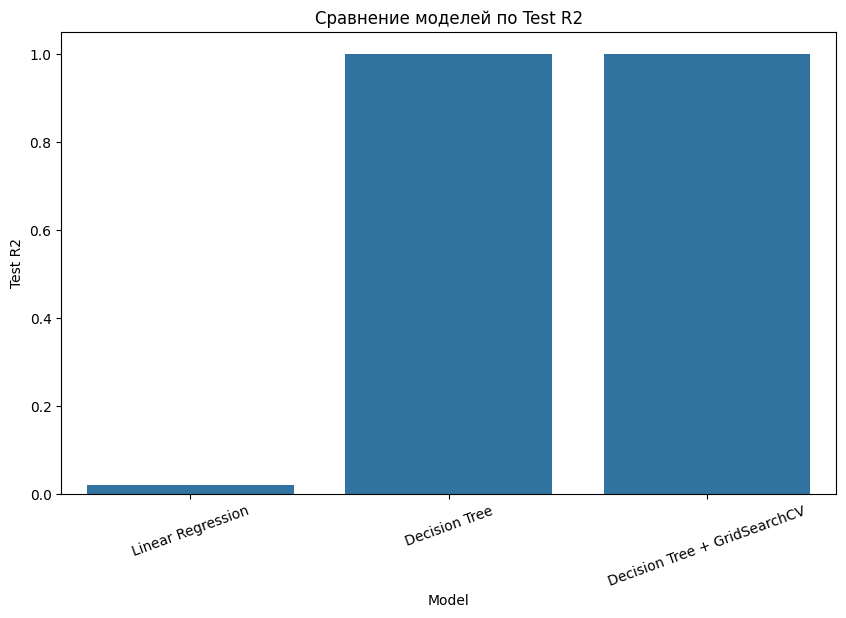

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Test R2", data=comparison)
plt.title("Сравнение моделей по Test R2")
plt.xticks(rotation=20)
plt.show()

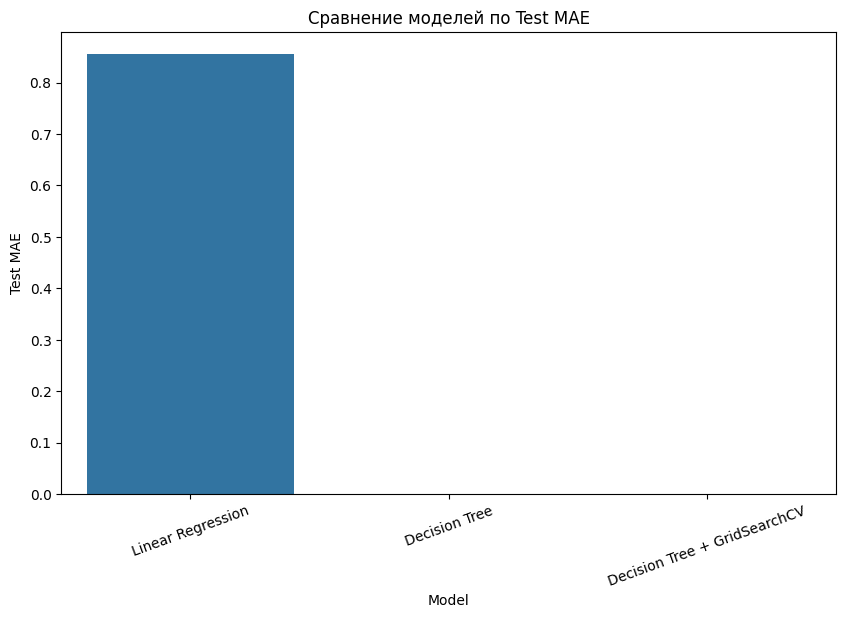

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Test MAE", data=comparison)
plt.title("Сравнение моделей по Test MAE")
plt.xticks(rotation=20)
plt.show()

## 11. Выводы

В ходе лабораторной работы были выполнены следующие действия:

- загружен подготовленный датасет из лабораторной работы №3;
- данные были разделены на обучающую и тестовую выборки;
- обучена базовая модель `Linear Regression`;
- обучена альтернативная модель `Decision Tree`;
- выполнен подбор гиперпараметров с помощью `GridSearchCV`;
- проведено сравнение моделей по метрикам `MAE`, `MSE` и `R2`;
- выполнен анализ переобучения.

По результатам сравнения можно сделать вывод, что обычное дерево решений может показывать высокий результат на обучающей выборке, но при этом хуже работать на тестовой выборке. Это говорит о возможном переобучении.

Модель после подбора гиперпараметров является более устойчивой, так как параметры дерева ограничивают его сложность. Поэтому лучшей моделью можно считать `Decision Tree + GridSearchCV`, если она показывает более высокий `Test R2` и меньшую ошибку `Test MAE` по сравнению с другими моделями.


В ходе лабораторной работы были выполнены следующие действия:

- загружен подготовленный датасет из лабораторной работы №3;
- данные были разделены на обучающую и тестовую выборки;
- обучена базовая модель `Linear Regression`;
- обучена альтернативная модель `Decision Tree`;
- выполнен подбор гиперпараметров с помощью `GridSearchCV`;
- проведено сравнение моделей по метрикам `MAE`, `MSE` и `R2`;
- выполнен анализ переобучения.

По результатам сравнения можно сделать вывод, что обычное дерево решений может показывать высокий результат на обучающей выборке, но при этом хуже работать на тестовой выборке. Это говорит о возможном переобучении.

Модель после подбора гиперпараметров является более устойчивой, так как параметры дерева ограничивают его сложность. Поэтому лучшей моделью можно считать `Decision Tree + GridSearchCV`, если она показывает более высокий `Test R2` и меньшую ошибку `Test MAE` по сравнению с другими моделями.